In [27]:
import sys
sys.path.append('..')

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from scipy import stats
from pathlib import Path

from src.signals.signal import compute_signals, load_signals
from src.portfolio.portfolio import compute_portfolio, load_weights
from src.data.prices import load_returns
from src.data.factors import load_factors, FACTOR_COLS
from src.utils.plotting import cumulative_return, drawdown, rolling_sharpe, performance_table
from src.utils.performance import summary_table, turnover
from src.utils.stats import bootstrap_sharpe_ci, newey_west_tstat, psr, factor_regression

plt.rcParams.update({
    'figure.figsize':    (13, 4),
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    plt.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

test_start = "2018-01-01"
test_end = "2024-12-31"

prices = load_returns()

In [28]:
# Recompute weights using point-in-time data for each rebalancing date
compute_signals()
compute_portfolio()

weights = load_weights()
dates = sorted(weights['rebal_date'].unique().to_list())
dates_str = [str(d) for d in dates]
print(f'Weights: {weights.shape}  |  {dates_str[0]} to {dates_str[-1]}')

2026-05-11 13:31:06.028 | INFO     | src.data.universe:get_rebalancing_dates:223 - Rebalancing dates: 216


2026-05-11 13:31:06.030 | INFO     | src.signals.signal:compute_signals:36 - Computing signals for 207 rebalancing dates.
2026-05-11 13:31:22.413 | INFO     | src.signals.signal:compute_signals:119 - Signals saved: C:\Users\ben88\OneDrive - McGill University\Desktop\evovest\toy_strategy\data\processed\signals\signals.parquet
2026-05-11 13:31:22.425 | INFO     | src.portfolio.portfolio:compute_portfolio:89 - Solving portfolio QP for 207 dates
Portfolio QP: 100%|██████████| 207/207 [00:15<00:00, 13.37it/s]
2026-05-11 13:31:37.937 | INFO     | src.portfolio.portfolio:compute_portfolio:151 - Weights saved: data\processed\portfolio\weights.parquet


Weights: (41607, 3)  |  2007-10-31 to 2024-12-31


In [29]:
# Evaluation window
dates_eval = [
    d for d in dates
    if (test_start is None or str(d) >= test_start)
    and (test_end is None or str(d) <= test_end)
 ]

if not dates_eval:
    raise ValueError("No dates in evaluation window. Check test_start/test_end.")

print(
    f"Evaluation window: {dates_eval[0]} to {dates_eval[-1]}  "
    f"({len(dates_eval)} dates)"
 )

Evaluation window: 2018-01-31 to 2024-12-31  (84 dates)


For each rebalancing period $[t, t+1]$, the portfolio return is:

$$R_t^{\text{port}} = \sum_{i=1}^{N_t} w_t^i \cdot r_{[t, t+1]}^i$$

where $r_{[t,t+1]}^i = \sum_{s=t+1}^{t+1} \log\frac{P_s^i}{P_{s-1}^i}$ is the cumulative log return over the holding period.

In [30]:
records = []

for i in range(len(dates_eval) - 1):
    d      = dates_eval[i]
    d_next = dates_eval[i + 1]

    # Weights held from d to d_next
    w = weights.filter(pl.col('rebal_date') == d).select(['symbol', 'weight'])

    # Cumulative stock returns over the holding period
    period_ret = (
        prices
        .filter(pl.col('date') > d)
        .filter(pl.col('date') <= d_next)
        .filter(pl.col('symbol').is_in(w['symbol'].to_list()))
        .group_by('symbol')
        .agg(pl.col('log_return').sum().alias('ret'))
        .drop_nulls()
    )

    merged = w.join(period_ret, on='symbol', how='inner')
    if len(merged) < 10:
        continue

    port_ret = float((merged['weight'] * merged['ret']).sum())
    turnover = float(w['weight'].abs().sum())  # gross exposure at rebalancing

    records.append({'date': d_next, 'return': port_ret, 'turnover': turnover})

ret_df   = pl.DataFrame(records).sort('date')
ret_arr  = ret_df['return'].to_numpy()
ret_dts  = [datetime.strptime(str(d), '%Y-%m-%d') for d in ret_df['date'].to_list()]

print(f'Monthly returns computed: {len(ret_arr)} observations')
print(f'Mean monthly return : {ret_arr.mean():.4f}')
print(f'Std monthly return  : {ret_arr.std():.4f}')

Monthly returns computed: 83 observations
Mean monthly return : 0.0078
Std monthly return  : 0.0673


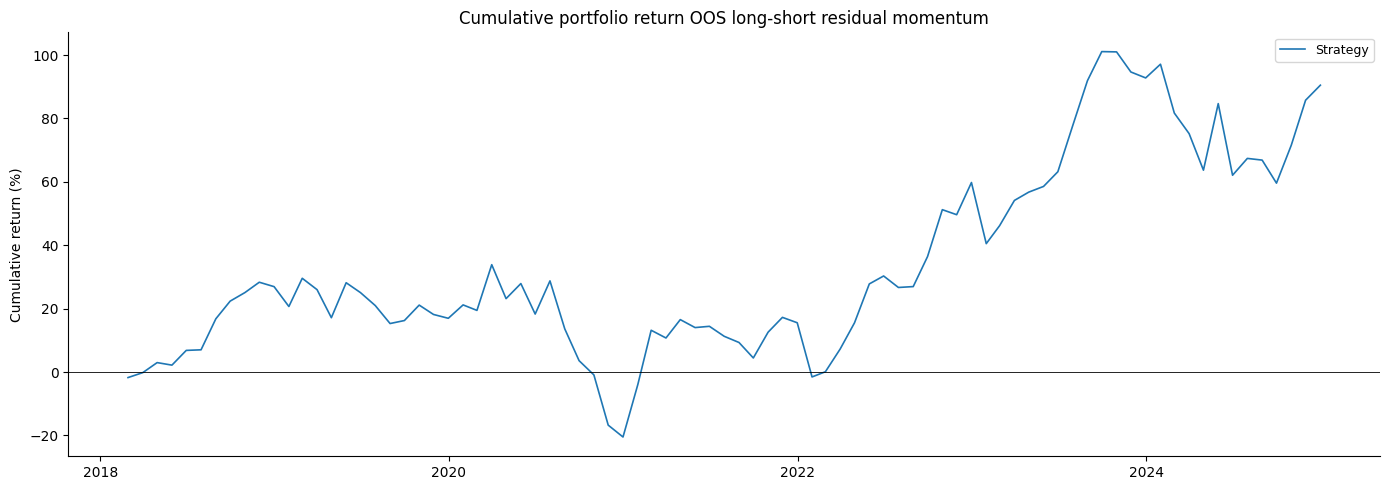

In [31]:
fig, ax = plt.subplots(figsize=(14, 5))
cumulative_return(ret_dts, {"Strategy": ret_arr}, ax=ax,
                  title="Cumulative portfolio return OOS long-short residual momentum")
plt.tight_layout()
save_fig("05_portfolio_cumulative.png")
plt.show()

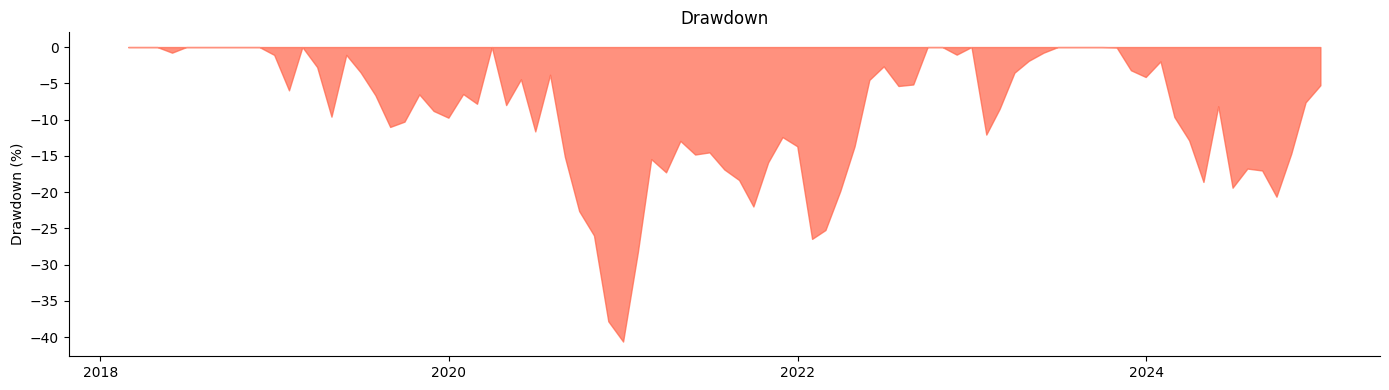

In [32]:
fig, ax = plt.subplots(figsize=(14, 4))
drawdown(ret_dts, ret_arr, ax=ax, title="Drawdown")
plt.tight_layout()
save_fig("05_portfolio_drawdown.png")
plt.show()

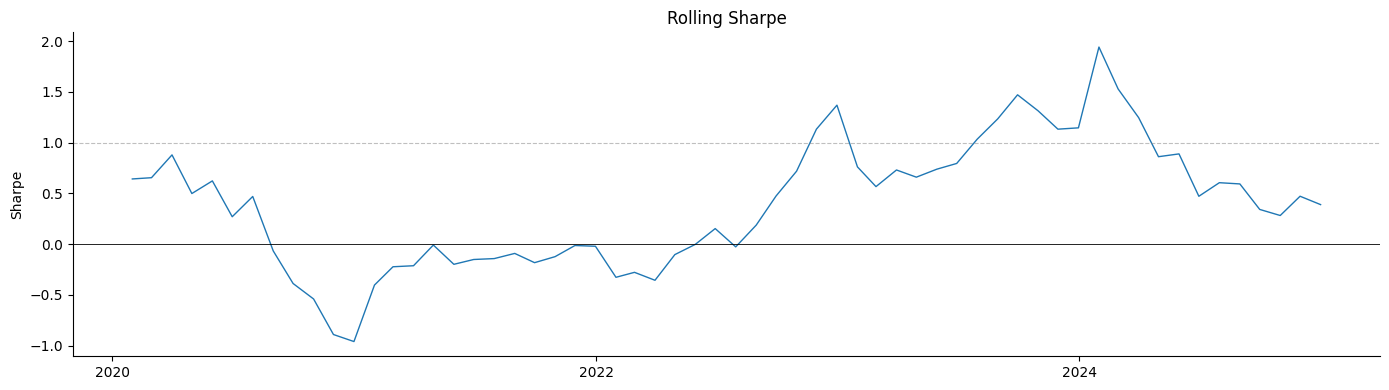

In [33]:
fig, ax = plt.subplots(figsize=(14, 4))
rolling_sharpe(ret_dts, ret_arr, window=24, periods_per_year=12, ax=ax)
plt.tight_layout()
save_fig("05_portfolio_rolling_sharpe.png")
plt.show()

In [34]:
summary = summary_table(ret_arr)
summary

lo, hi = bootstrap_sharpe_ci(ret_arr, periods_per_year=12, n_boot=2000, ci=0.95)
print(f"Sharpe 95% CI: [{lo:.3f}, {hi:.3f}]")

t_nw = newey_west_tstat(ret_arr, max_lag=6)
print(f"NW t-stat (mean return): {t_nw:.3f}")

sr_hat = summary['sharpe']
psr_val = psr(sr_hat, 0.0, len(ret_arr), skew=stats.skew(ret_arr), kurt=stats.kurtosis(ret_arr))
print(f"PSR(Sharpe>0): {psr_val:.3f}")

Sharpe 95% CI: [-0.293, 1.130]
NW t-stat (mean return): 1.143
PSR(Sharpe>0): 1.000


In [35]:
factors = load_factors()

factor_records = []
for i in range(len(dates_eval) - 1):
    d = dates_eval[i]
    d_next = dates_eval[i + 1]
    fwd = (
        factors
        .filter(pl.col('date') > d)
        .filter(pl.col('date') <= d_next)
        .select(FACTOR_COLS)
    )
    if fwd.is_empty():
        continue
    factor_records.append({c: float(fwd[c].sum()) for c in FACTOR_COLS})

factor_df = pl.DataFrame(factor_records)
factor_mat = factor_df.select(FACTOR_COLS).to_numpy()
reg = factor_regression(ret_arr, factor_mat, factor_names=FACTOR_COLS)
reg

{'params': {'alpha': np.float64(0.005347976666141564),
  'mkt_rf': np.float64(-0.06737917643055547),
  'smb': np.float64(0.7566277678675013),
  'hml': np.float64(-0.15616315770424571),
  'rmw': np.float64(0.5406159108424963),
  'cma': np.float64(0.24063918039228538),
  'mom': np.float64(0.8280104907165828)},
 'se': {'alpha': np.float64(0.00784163226886344),
  'mkt_rf': np.float64(0.1253655208563133),
  'smb': np.float64(0.3367536765445428),
  'hml': np.float64(0.3041262714863098),
  'rmw': np.float64(0.31402612411381275),
  'cma': np.float64(0.3295718708614629),
  'mom': np.float64(0.1740197170937885)},
 'tstat': {'alpha': np.float64(0.6819978905892632),
  'mkt_rf': np.float64(-0.5374617835136789),
  'smb': np.float64(2.2468285294798296),
  'hml': np.float64(-0.5134813146560914),
  'rmw': np.float64(1.7215634921079381),
  'cma': np.float64(0.7301569146762504),
  'mom': np.float64(4.758141804530827)},
 'r_squared': 0.2283143542367867}

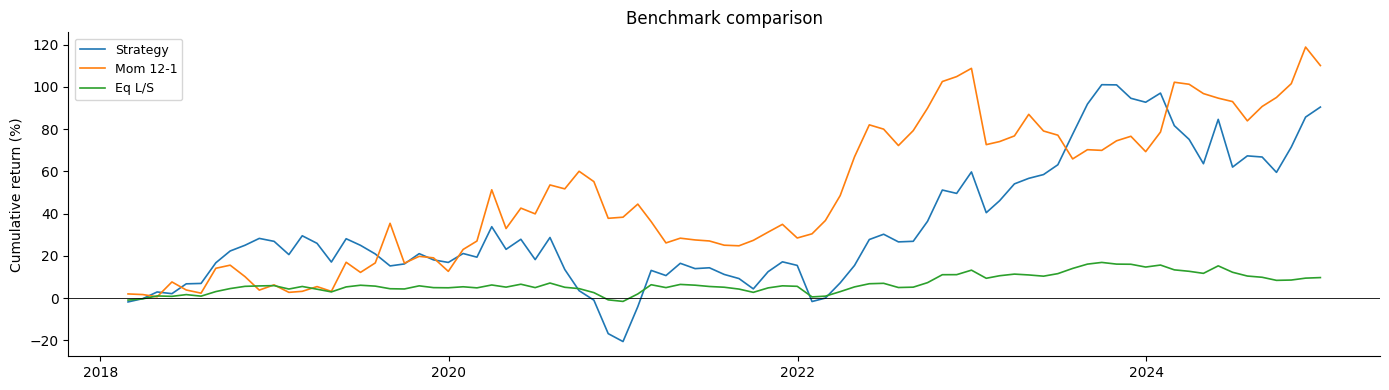

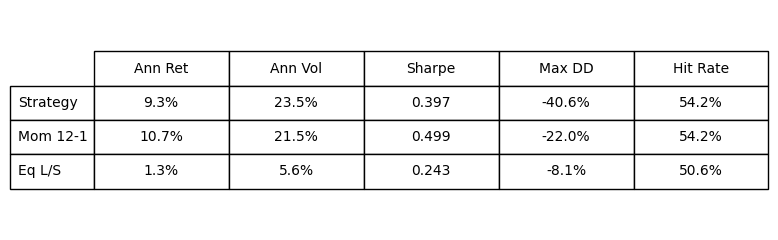

In [36]:
signals = load_signals()

mom_records = []
eq_records = []

for i in range(len(dates_eval) - 1):
    d = dates_eval[i]
    d_next = dates_eval[i + 1]

    start = d - timedelta(days=365)
    end = d - timedelta(days=21)

    mom = (
        prices
        .filter(pl.col('date') > start)
        .filter(pl.col('date') <= end)
        .group_by('symbol')
        .agg(pl.col('log_return').sum().alias('mom'))
        .drop_nulls()
        .sort('mom')
    )
    if len(mom) < 20:
        continue

    n = len(mom)
    k = max(1, int(0.1 * n))
    bottom = mom.head(k).select(['symbol']).with_columns(pl.lit(-1.0 / k).alias('weight'))
    top = mom.tail(k).select(['symbol']).with_columns(pl.lit(1.0 / k).alias('weight'))
    w_mom = pl.concat([bottom, top])

    period_ret = (
        prices
        .filter(pl.col('date') > d)
        .filter(pl.col('date') <= d_next)
        .filter(pl.col('symbol').is_in(w_mom['symbol'].to_list()))
        .group_by('symbol')
        .agg(pl.col('log_return').sum().alias('ret'))
        .drop_nulls()
    )
    merged = w_mom.join(period_ret, on='symbol', how='inner')
    if len(merged) >= 10:
        mom_ret = float((merged['weight'] * merged['ret']).sum())
        mom_records.append({'date': d_next, 'return': mom_ret})

    sig = (
        signals
        .filter(pl.col('rebal_date') == d)
        .select(['symbol', 'z_score'])
        .drop_nulls()
    )
    longs = sig.filter(pl.col('z_score') > 0)
    shorts = sig.filter(pl.col('z_score') < 0)
    if len(longs) < 10 or len(shorts) < 10:
        continue
    w_eq = pl.concat([
        longs.select(['symbol']).with_columns(pl.lit(1.0 / len(longs)).alias('weight')),
        shorts.select(['symbol']).with_columns(pl.lit(-1.0 / len(shorts)).alias('weight')),
    ])

    period_ret_eq = (
        prices
        .filter(pl.col('date') > d)
        .filter(pl.col('date') <= d_next)
        .filter(pl.col('symbol').is_in(w_eq['symbol'].to_list()))
        .group_by('symbol')
        .agg(pl.col('log_return').sum().alias('ret'))
        .drop_nulls()
    )
    merged_eq = w_eq.join(period_ret_eq, on='symbol', how='inner')
    if len(merged_eq) >= 10:
        eq_ret = float((merged_eq['weight'] * merged_eq['ret']).sum())
        eq_records.append({'date': d_next, 'return': eq_ret})

mom_df = pl.DataFrame(mom_records).sort('date')
eq_df = pl.DataFrame(eq_records).sort('date')

base = ret_df.select(['date', 'return']).rename({'return': 'strategy'})
mom_j = base.join(mom_df.rename({'return': 'momentum'}), on='date', how='inner')
eq_j = base.join(eq_df.rename({'return': 'equal_weight'}), on='date', how='inner')
joined = mom_j.join(eq_j.select(['date', 'equal_weight']), on='date', how='inner')

dates_b = [datetime.strptime(str(d), '%Y-%m-%d') for d in joined['date'].to_list()]
r_strategy = joined['strategy'].to_numpy()
r_mom = joined['momentum'].to_numpy()
r_eq = joined['equal_weight'].to_numpy()

fig, ax = plt.subplots(figsize=(14, 4))
cumulative_return(dates_b, {"Strategy": r_strategy, "Mom 12-1": r_mom, "Eq L/S": r_eq}, ax=ax,
                  title="Benchmark comparison")
plt.tight_layout()
save_fig("05_portfolio_benchmark_cum.png")
plt.show()

summaries = {
    "Strategy": summary_table(r_strategy),
    "Mom 12-1": summary_table(r_mom),
    "Eq L/S": summary_table(r_eq),
}
fig, ax = plt.subplots(figsize=(8, 2.5))
performance_table(summaries, ax=ax)
plt.tight_layout()
save_fig("05_portfolio_benchmark_table.png")
plt.show()